VAL merged: (3944, 14)
TEST merged: (4182, 14)


,split,feature,pearson_r,spearman_r,mae,mse,raw_mean,zstar_mean,raw_std,zstar_std
0,val,A_diag_mean,0.371570,0.503183,0.382303,0.241080,-5.325062,-4.998419,0.393324,0.113924
1,val,A_offdiag_mean,0.846024,0.753594,0.074234,0.012698,-0.550037,-0.553447,0.210738,0.170376
2,val,B_diag_mean,0.729285,0.747797,0.098908,0.013121,-4.561789,-4.469139,0.096082,0.084736
3,val,B_offdiag_mean,0.765830,0.738398,0.041427,0.003460,-1.509007,-1.489819,0.076618,0.032900
4,val,C_mean,0.488239,0.475012,0.103455,0.015893,-0.397710,-0.472079,0.116202,0.047874
5,val,trace_mean,0.601713,0.605755,0.136495,0.027197,-4.851795,-4.733779,0.143876,0.078564


,split,feature,pearson_r,spearman_r,mae,mse,raw_mean,zstar_mean,raw_std,zstar_std
0,test,A_diag_mean,0.524124,0.505448,0.382456,0.208217,-5.338505,-5.002204,0.352722,0.114993
1,test,A_offdiag_mean,0.900992,0.719781,0.070255,0.008297,-0.583073,-0.555352,0.198511,0.168264
2,test,B_diag_mean,0.676301,0.740032,0.109569,0.015975,-4.571428,-4.471096,0.103971,0.076832
3,test,B_offdiag_mean,0.751078,0.759217,0.056042,0.004993,-1.530393,-1.492484,0.080469,0.033360
4,test,C_mean,0.443143,0.414438,0.077153,0.009292,-0.446399,-0.475601,0.102475,0.045018
5,test,trace_mean,0.610371,0.611943,0.147211,0.031786,-4.861180,-4.736650,0.158675,0.074926


,split,feature,auroc,direction,pos_mean,neg_mean
0,val,A_diag_mean,0.801762,higher -> positive,-4.938306,-5.056848
5,val,trace_mean,0.768735,higher -> positive,-4.700256,-4.766363
1,val,A_offdiag_mean,0.748450,lower -> positive,-0.622430,-0.486396
3,val,B_offdiag_mean,0.716454,higher -> positive,-1.478492,-1.500830
2,val,B_diag_mean,0.705582,higher -> positive,-4.462206,-4.475877
4,val,C_mean,0.648364,lower -> positive,-0.483780,-0.460705


,split,feature,auroc,direction,pos_mean,neg_mean
0,test,A_diag_mean,0.819641,higher -> positive,-4.941603,-5.068320
3,test,B_offdiag_mean,0.812508,higher -> positive,-1.480194,-1.505892
5,test,trace_mean,0.789415,higher -> positive,-4.701529,-4.774967
1,test,A_offdiag_mean,0.742422,lower -> positive,-0.618369,-0.486601
2,test,B_diag_mean,0.723863,higher -> positive,-4.461456,-4.481614
4,test,C_mean,0.624246,lower -> positive,-0.484444,-0.465954


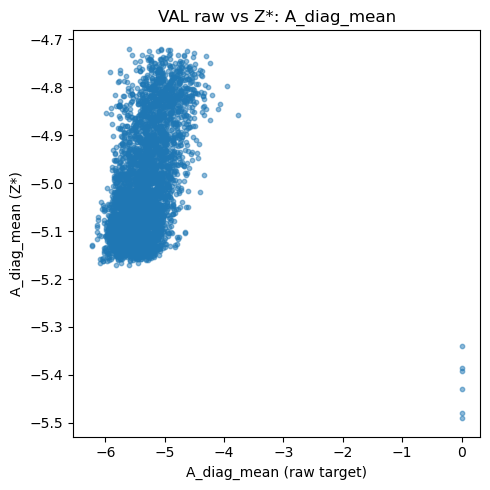

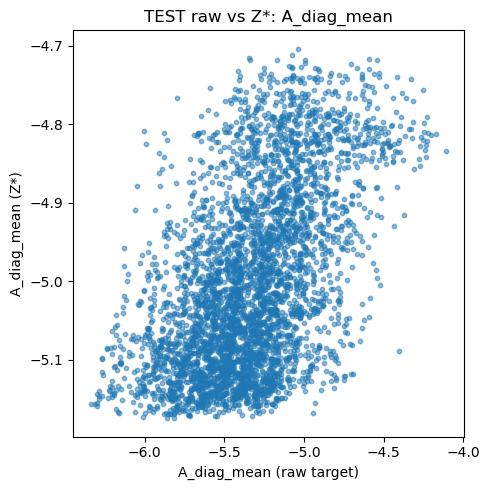

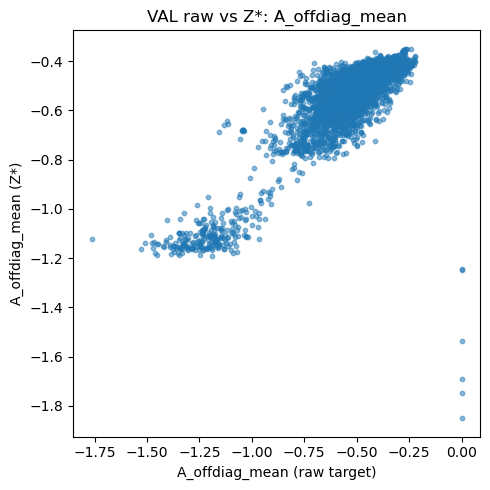

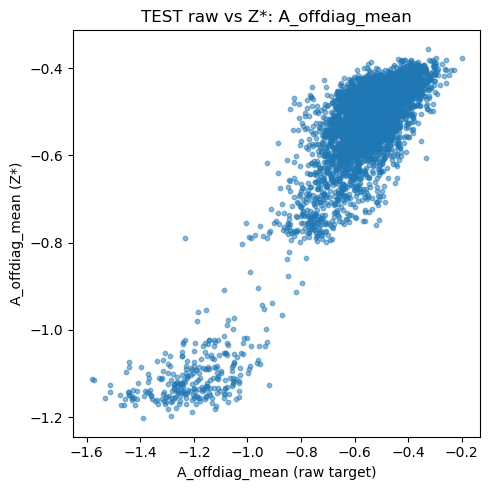

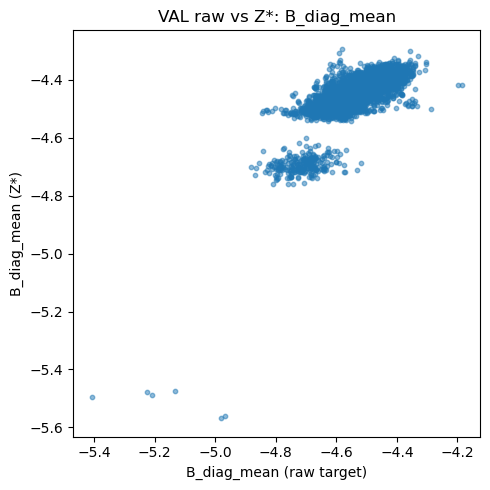

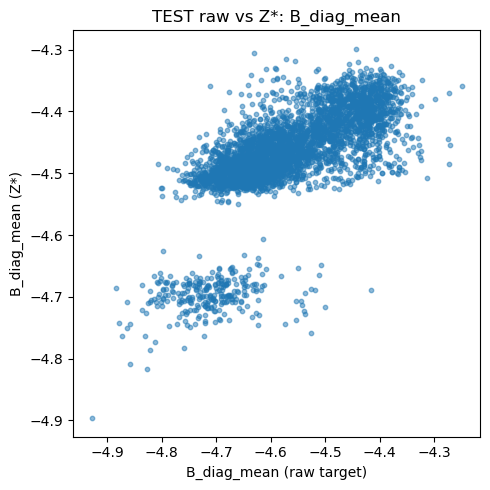

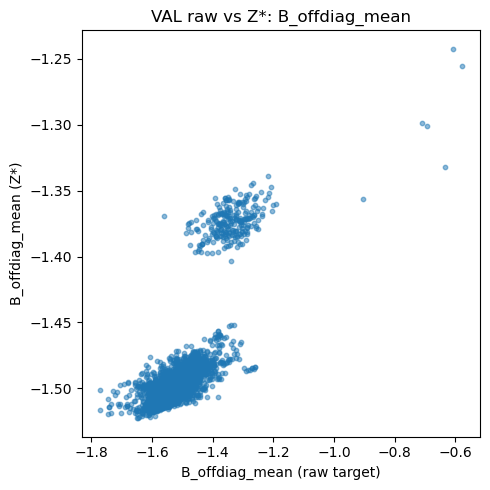

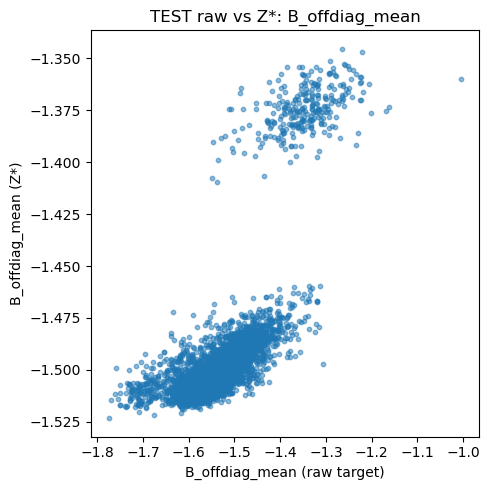

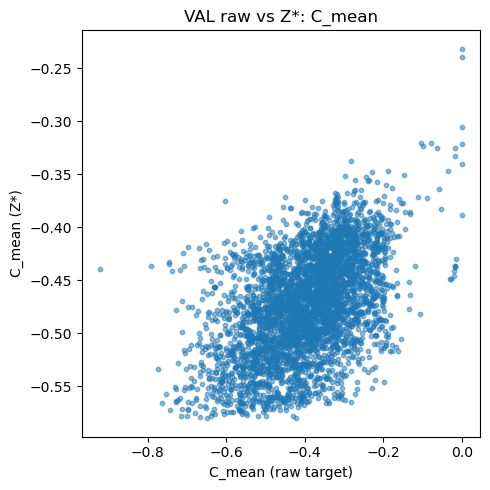

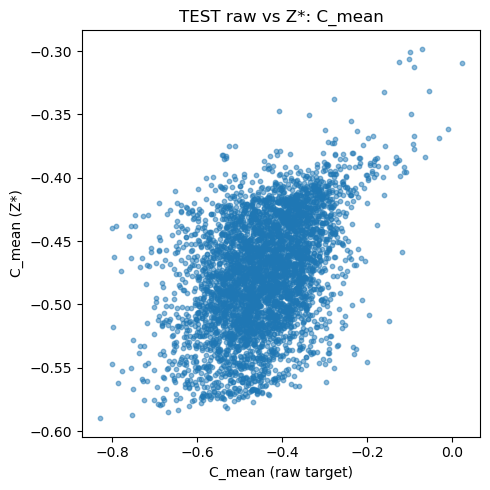

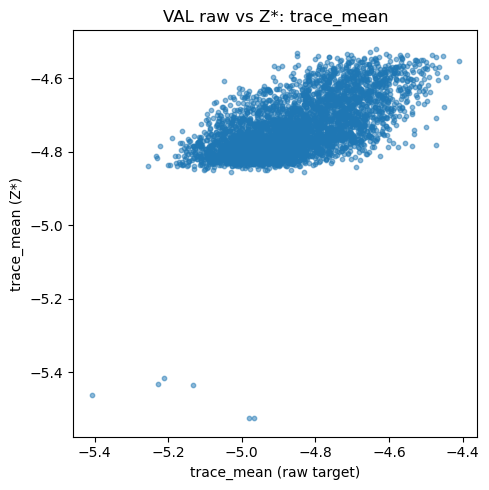

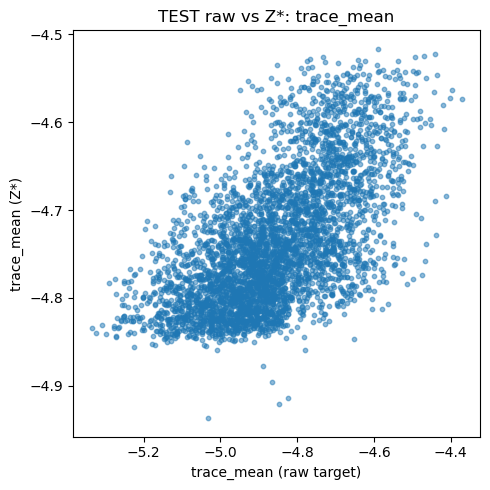

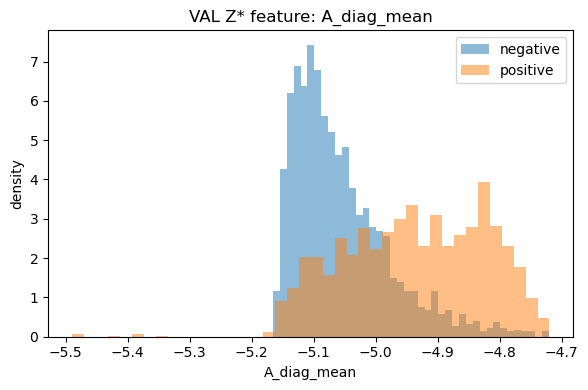

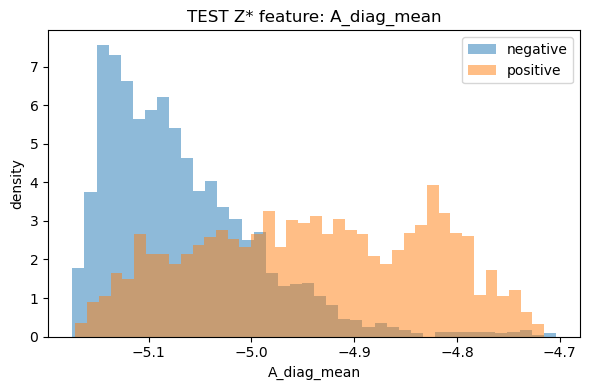

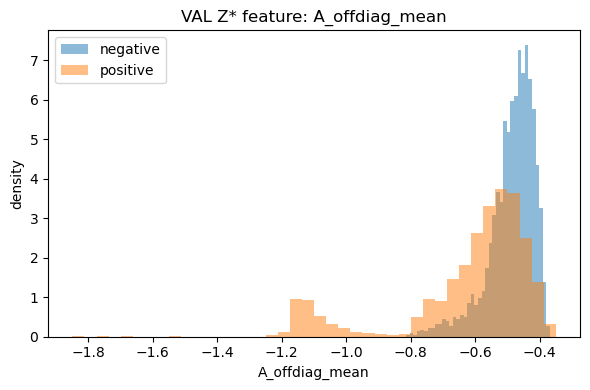

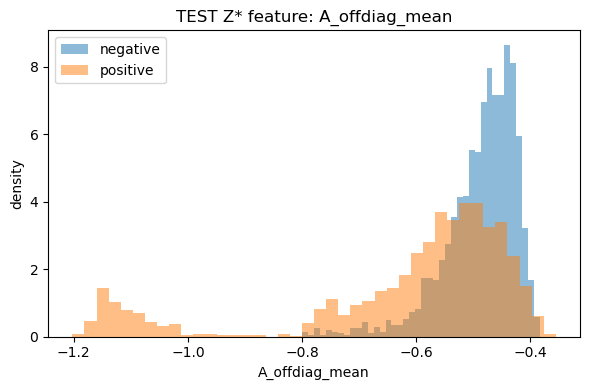

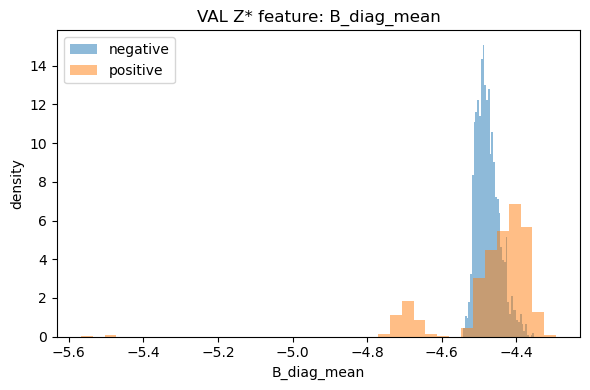

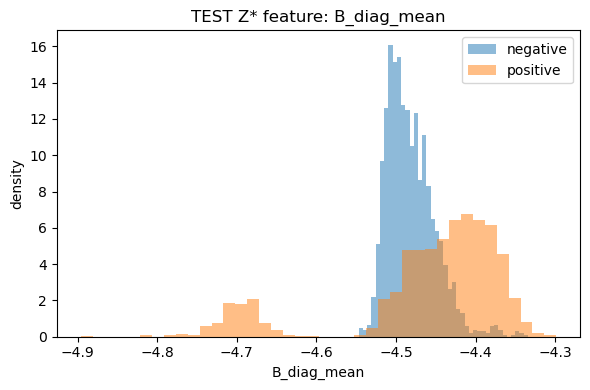

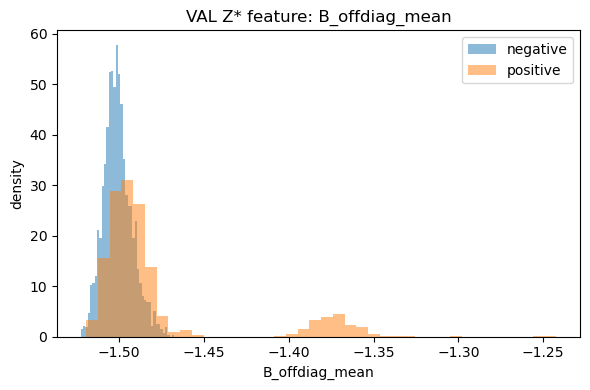

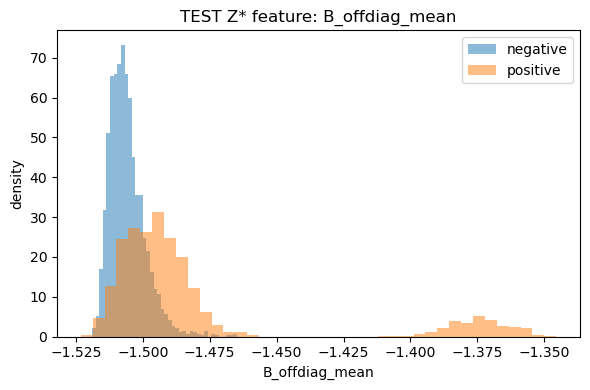

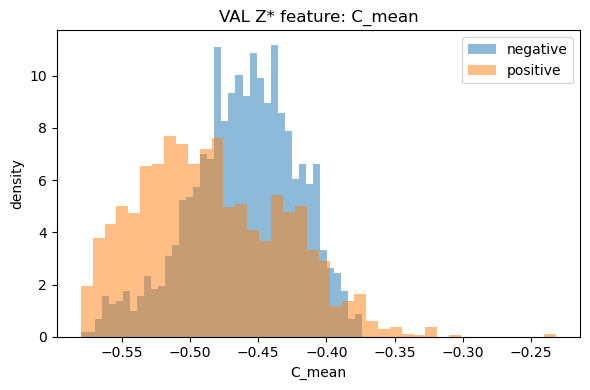

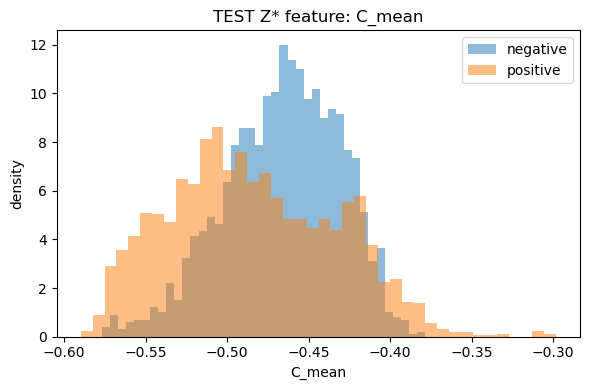

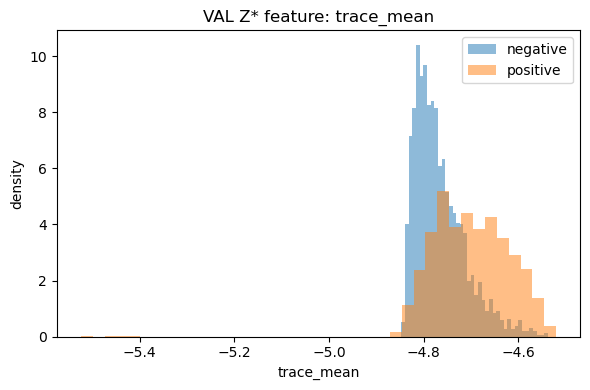

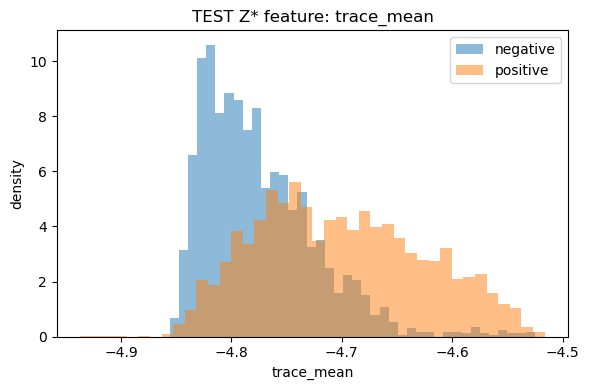

In [2]:
# ============================================================
# ANALYSE WHETHER RECONSTRUCTED Z* PRESERVES THE TARGET METRICS
# ============================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr, pearsonr

# ----------------------------
# PATHS: adjust if needed
# ----------------------------

BASE = Path("/home/natasha/multimodal_model")

# Raw cached targets from training script
FEATURE_CACHE_DIR = BASE / "models/feature_cache/boltz_signal_targets"

# Best exported artifacts from training script
BEST_EXPORT_DIR = BASE / "models/embeddings/boltz_signal_bottleneck_previews" / "best_epoch_001"   # <-- change epoch if needed

VAL_META = BEST_EXPORT_DIR / "val_metadata.csv"
VAL_ZSTAR = BEST_EXPORT_DIR / "val_zstar_residual.npz"

TEST_META = BEST_EXPORT_DIR / "test_metadata.csv"
TEST_ZSTAR = BEST_EXPORT_DIR / "test_zstar_residual.npz"

VAL_RAW_CACHE = FEATURE_CACHE_DIR / "val_raw_target_features.csv"
TEST_RAW_CACHE = FEATURE_CACHE_DIR / "test_raw_target_features.csv"

TARGET_FEATURE_NAMES = [
    "A_diag_mean",
    "A_offdiag_mean",
    "B_diag_mean",
    "B_offdiag_mean",
    "C_mean",
    "trace_mean",
]

# ----------------------------
# FEATURE COMPUTATION ON Z*
# ----------------------------

def strict_upper_mean_np(mat: np.ndarray) -> float:
    n = mat.shape[0]
    if n <= 1:
        return 0.0
    iu = np.triu_indices(n, k=1)
    vals = mat[iu]
    if vals.size == 0:
        return 0.0
    return float(vals.mean())

def compute_zstar_features(zstar_residual: np.ndarray) -> dict:
    """
    zstar_residual: [2d, 2d]
    Features must match the training script's zstar_features(...) logic.
    """
    D = zstar_residual.shape[0]
    d = D // 2

    A = zstar_residual[:d, :d]
    C = zstar_residual[:d, d:]
    B = zstar_residual[d:, d:]

    return {
        "A_diag_mean": float(np.diag(A).mean()),
        "A_offdiag_mean": strict_upper_mean_np(A),
        "B_diag_mean": float(np.diag(B).mean()),
        "B_offdiag_mean": strict_upper_mean_np(B),
        "C_mean": float(C.mean()),
        "trace_mean": float(np.trace(zstar_residual) / D),
    }

def load_exported_zstar_features(meta_csv, zstar_npz):
    meta = pd.read_csv(meta_csv)
    zstars = np.load(zstar_npz)["zstar_residual"]   # [N, 2d, 2d]

    rows = []
    for i in range(len(meta)):
        feats = compute_zstar_features(zstars[i])
        feats["pair_id"] = str(meta.iloc[i]["pair_id"])
        feats["binding_flag"] = int(meta.iloc[i]["binding_flag"])
        rows.append(feats)

    feat_df = pd.DataFrame(rows)
    return feat_df

# ----------------------------
# LOAD RAW + RECONSTRUCTED
# ----------------------------

raw_val = pd.read_csv(VAL_RAW_CACHE)
raw_test = pd.read_csv(TEST_RAW_CACHE)

zstar_val = load_exported_zstar_features(VAL_META, VAL_ZSTAR)
zstar_test = load_exported_zstar_features(TEST_META, TEST_ZSTAR)

# Merge by pair_id
cmp_val = raw_val[["pair_id"] + TARGET_FEATURE_NAMES].merge(
    zstar_val[["pair_id", "binding_flag"] + TARGET_FEATURE_NAMES],
    on="pair_id",
    suffixes=("_raw", "_zstar"),
    how="inner",
)

cmp_test = raw_test[["pair_id"] + TARGET_FEATURE_NAMES].merge(
    zstar_test[["pair_id", "binding_flag"] + TARGET_FEATURE_NAMES],
    on="pair_id",
    suffixes=("_raw", "_zstar"),
    how="inner",
)

print("VAL merged:", cmp_val.shape)
print("TEST merged:", cmp_test.shape)

# ----------------------------
# AGREEMENT METRICS
# ----------------------------

def agreement_table(df, split_name):
    rows = []
    for feat in TARGET_FEATURE_NAMES:
        x = df[f"{feat}_raw"].values
        y = df[f"{feat}_zstar"].values

        pear_r = pearsonr(x, y)[0] if np.std(x) > 0 and np.std(y) > 0 else np.nan
        spear_r = spearmanr(x, y).correlation if np.std(x) > 0 and np.std(y) > 0 else np.nan
        mae = np.mean(np.abs(x - y))
        mse = np.mean((x - y) ** 2)

        rows.append({
            "split": split_name,
            "feature": feat,
            "pearson_r": pear_r,
            "spearman_r": spear_r,
            "mae": mae,
            "mse": mse,
            "raw_mean": np.mean(x),
            "zstar_mean": np.mean(y),
            "raw_std": np.std(x),
            "zstar_std": np.std(y),
        })
    return pd.DataFrame(rows)

agree_val = agreement_table(cmp_val, "val")
agree_test = agreement_table(cmp_test, "test")

display(agree_val)
display(agree_test)

# ----------------------------
# POS/NEG SEPARATION ON Z*
# ----------------------------

def separation_table(df, split_name):
    rows = []
    y = df["binding_flag"].values.astype(int)

    for feat in TARGET_FEATURE_NAMES:
        x = df[feat].values.astype(float)

        if np.std(x) == 0:
            auroc = np.nan
            direction = "constant"
        else:
            auroc_hi = roc_auc_score(y, x)
            auroc_lo = roc_auc_score(y, -x)
            if auroc_hi >= auroc_lo:
                auroc = auroc_hi
                direction = "higher -> positive"
            else:
                auroc = auroc_lo
                direction = "lower -> positive"

        rows.append({
            "split": split_name,
            "feature": feat,
            "auroc": auroc,
            "direction": direction,
            "pos_mean": df.loc[df.binding_flag == 1, feat].mean(),
            "neg_mean": df.loc[df.binding_flag == 0, feat].mean(),
        })
    return pd.DataFrame(rows).sort_values("auroc", ascending=False)

sep_val = separation_table(zstar_val, "val")
sep_test = separation_table(zstar_test, "test")

display(sep_val)
display(sep_test)

# ----------------------------
# PLOTS
# ----------------------------

def plot_raw_vs_zstar_scatter(df, split_name, feature):
    x = df[f"{feature}_raw"].values
    y = df[f"{feature}_zstar"].values

    plt.figure(figsize=(5, 5))
    plt.scatter(x, y, s=10, alpha=0.5)
    plt.xlabel(f"{feature} (raw target)")
    plt.ylabel(f"{feature} (Z*)")
    plt.title(f"{split_name.upper()} raw vs Z*: {feature}")
    plt.tight_layout()
    plt.show()

def plot_zstar_hist(df, split_name, feature, bins=40):
    pos = df.loc[df.binding_flag == 1, feature].values
    neg = df.loc[df.binding_flag == 0, feature].values

    plt.figure(figsize=(6, 4))
    plt.hist(neg, bins=bins, alpha=0.5, density=True, label="negative")
    plt.hist(pos, bins=bins, alpha=0.5, density=True, label="positive")
    plt.xlabel(feature)
    plt.ylabel("density")
    plt.title(f"{split_name.upper()} Z* feature: {feature}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot all
for feat in TARGET_FEATURE_NAMES:
    plot_raw_vs_zstar_scatter(cmp_val, "val", feat)
    plot_raw_vs_zstar_scatter(cmp_test, "test", feat)

for feat in TARGET_FEATURE_NAMES:
    plot_zstar_hist(zstar_val, "val", feat)
    plot_zstar_hist(zstar_test, "test", feat)